# Emotion Classification From Mel Spectrograms With a Simple CNN


This notebook builds an emotion-classification pipeline using the RAVDESS speech dataset and a compact CNN trained directly on fixed-size log-mel spectrograms.

The workflow:
- parses the RAVDESS filenames to recover the emotion labels
- trims silence and normalizes each waveform
- forces every clip to the same duration
- converts each clip into a fixed-size log-mel spectrogram
- feeds the spectrogram into a small CNN for **emotion-only** classification
- evaluates on an actor-wise held-out split and saves a report


In [1]:
from __future__ import annotations

import json
import random
from pathlib import Path

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, ConfusionMatrixDisplay
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from tensorflow import keras
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

tf.config.experimental.enable_op_determinism()


Libraries used in this notebook:
- `librosa` and `soundfile` for audio processing
- `numpy`, `pandas`, and `matplotlib` for analysis and visualization
- `scikit-learn` for splitting and evaluation
- `TensorFlow / Keras` for the CNN classifier


In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'actors_speech').exists() and (PROJECT_ROOT.parent / 'actors_speech').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / 'actors_speech'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts' / 'simple_cnn_emotion'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_RATE = 16_000
N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 256
TARGET_SPEC_FRAMES = 160
LOG_MEL_MIN_DB = -80.0
LOG_MEL_MAX_DB = 0.0
TOP_DB = 30
BATCH_SIZE = 16
EPOCHS = 50
PATIENCE = 4
LEARNING_RATE = 1e-3
NEUTRAL_OVERSAMPLE_FACTOR = 3
NEUTRAL_CLASS_WEIGHT_MULTIPLIER = 1.5
TARGET_LENGTH_PERCENTILE = 75

print('Project root:', PROJECT_ROOT)
print('Data dir exists:', DATA_DIR.exists())
print('Artifacts dir:', ARTIFACTS_DIR)
print('CNN spectrogram shape:', (N_MELS, TARGET_SPEC_FRAMES, 1))
print('Batch size:', BATCH_SIZE)


Project root: /Users/jainil/PycharmProjects/DataScienceAudioProject
Data dir exists: True
Artifacts dir: /Users/jainil/PycharmProjects/DataScienceAudioProject/artifacts/simple_cnn_emotion
CNN spectrogram shape: (128, 160, 1)
Batch size: 16


## 3. Parse the Dataset Labels

RAVDESS filenames follow the pattern:
- `MM-VC-EE-II-SS-RR-AA`

For this notebook, we use only:
- `EE` for emotion label
- `AA` for actor ID

We ignore intensity for this CNN experiment.


In [3]:
EMOTION_MAP = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised',
}


def list_audio_files(data_dir: Path) -> list[Path]:
    return sorted(data_dir.glob('Actor_*/*.wav'))


def parse_ravdess_record(path: Path) -> dict:
    parts = path.stem.split('-')
    if len(parts) != 7:
        return {'path': str(path), 'parse_ok': False}

    modality, channel, emotion_code, intensity_code, statement_code, repetition_code, actor_code = parts
    return {
        'path': str(path),
        'parse_ok': True,
        'emotion_code': emotion_code,
        'emotion': EMOTION_MAP.get(emotion_code, 'unknown'),
        'actor_id': int(actor_code),
        'statement_code': statement_code,
        'repetition_code': repetition_code,
    }

records = pd.DataFrame(parse_ravdess_record(p) for p in list_audio_files(DATA_DIR))
records = records[records['parse_ok']].copy().reset_index(drop=True)
records = records[records['emotion'] != 'unknown'].reset_index(drop=True)

emotion_labels = sorted(records['emotion'].unique())
emotion_to_idx = {label: idx for idx, label in enumerate(emotion_labels)}
idx_to_emotion = {idx: label for label, idx in emotion_to_idx.items()}
records['label_idx'] = records['emotion'].map(emotion_to_idx)

print('Number of clips:', len(records))
print('Emotion classes:', emotion_labels)
records.head()

Number of clips: 1440
Emotion classes: ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']


,path,parse_ok,emotion_code,emotion,actor_id,statement_code,repetition_code,label_idx
0,/Users/jainil/PycharmProjects/DataScienceAudio...,True,01,neutral,1,01,01,5
1,/Users/jainil/PycharmProjects/DataScienceAudio...,True,01,neutral,1,01,02,5
2,/Users/jainil/PycharmProjects/DataScienceAudio...,True,01,neutral,1,02,01,5
3,/Users/jainil/PycharmProjects/DataScienceAudio...,True,01,neutral,1,02,02,5
4,/Users/jainil/PycharmProjects/DataScienceAudio...,True,02,calm,1,01,01,1


## 4. Inspect the Class Distribution

Before training, we verify how many clips belong to each emotion class.


,count
emotion,
angry,192
calm,192
disgust,192
fearful,192
happy,192
neutral,96
sad,192
surprised,192


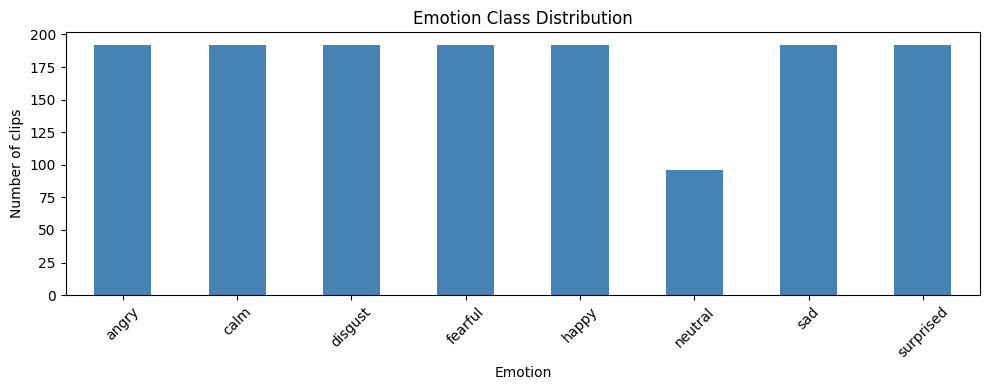

In [4]:
emotion_counts = records['emotion'].value_counts().sort_index()
display(emotion_counts.to_frame('count'))

plt.figure(figsize=(10, 4))
emotion_counts.plot(kind='bar', color='steelblue')
plt.title('Emotion Class Distribution')
plt.xlabel('Emotion')
plt.ylabel('Number of clips')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Audio Cleaning and Fixed-Length Processing

This is the key preprocessing function used throughout the notebook.

Steps:
1. load audio at 16 kHz
2. peak-normalize the waveform
3. remove leading and trailing silence
4. pad or crop the waveform to exactly the same number of samples

Because every clip ends with the same waveform length, every log-mel spectrogram will also have the same shape.


In [5]:
def trim_or_pad_to_length(y: np.ndarray, target_num_samples: int) -> np.ndarray:
    if len(y) >= target_num_samples:
        start = (len(y) - target_num_samples) // 2
        return y[start:start + target_num_samples].astype(np.float32)

    if len(y) == 0:
        return np.zeros(target_num_samples, dtype=np.float32)

    repeats = int(np.ceil(target_num_samples / len(y)))
    tiled = np.tile(y, repeats)[:target_num_samples]
    return tiled.astype(np.float32)


def trim_or_pad_spectrogram(spec: np.ndarray, target_frames: int = TARGET_SPEC_FRAMES) -> np.ndarray:
    current_frames = spec.shape[1]
    if current_frames >= target_frames:
        start = (current_frames - target_frames) // 2
        return spec[:, start:start + target_frames].astype(np.float32)

    repeats = int(np.ceil(target_frames / current_frames))
    tiled = np.tile(spec, (1, repeats))[:, :target_frames]
    return tiled.astype(np.float32)


def load_trimmed_audio(path: str | Path, sample_rate: int | None = None, top_db: int | None = None) -> tuple[np.ndarray, int]:
    if sample_rate is None:
        sample_rate = globals().get('SAMPLE_RATE', 16000)
    if top_db is None:
        top_db = globals().get('TOP_DB', 30)
    y, sr = librosa.load(path, sr=sample_rate, mono=True)
    y = librosa.util.normalize(y)
    y, _ = librosa.effects.trim(y, top_db=top_db)
    return y.astype(np.float32), sr


trimmed_lengths = []
for path in tqdm(records['path'], desc='Measuring trimmed clip lengths'):
    y_trimmed, _ = load_trimmed_audio(path)
    trimmed_lengths.append(len(y_trimmed))

TARGET_NUM_SAMPLES = int(np.percentile(trimmed_lengths, globals().get('TARGET_LENGTH_PERCENTILE', 75)))
DURATION_SECONDS = TARGET_NUM_SAMPLES / globals().get('SAMPLE_RATE', 16000)

print('Minimum trimmed waveform length:', int(np.min(trimmed_lengths)))
print('Median trimmed waveform length:', int(np.median(trimmed_lengths)))
print('75th percentile trimmed waveform length:', int(np.percentile(trimmed_lengths, 75)))
print('Chosen target waveform length:', TARGET_NUM_SAMPLES)
print('Derived duration seconds:', round(DURATION_SECONDS, 4))


def load_clean_audio(path: str | Path, sample_rate: int | None = None, top_db: int | None = None) -> tuple[np.ndarray, int]:
    y, sr = load_trimmed_audio(path, sample_rate=sample_rate, top_db=top_db)
    y = trim_or_pad_to_length(y, TARGET_NUM_SAMPLES)
    return y.astype(np.float32), sr


def waveform_to_log_mel(y: np.ndarray, sr: int = SAMPLE_RATE) -> np.ndarray:
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
    )
    log_mel = librosa.power_to_db(mel, ref=1.0, top_db=80.0)
    log_mel = np.clip(log_mel, LOG_MEL_MIN_DB, LOG_MEL_MAX_DB)
    log_mel = trim_or_pad_spectrogram(log_mel, target_frames=TARGET_SPEC_FRAMES)
    return log_mel.astype(np.float32)


Measuring trimmed clip lengths:   0%|          | 0/1440 [00:00<?, ?it/s]

Minimum trimmed waveform length: 18432
Median trimmed waveform length: 28672
75th percentile trimmed waveform length: 33792
Chosen target waveform length: 33792
Derived duration seconds: 2.112


## 6. Verify That All Waveforms and Spectrograms Have the Same Size

This cell checks a few examples after cleaning.


In [6]:
sample_paths = records['path'].sample(n=3, random_state=SEED).tolist()
processed_lengths = []
spectrogram_shapes = []

for p in sample_paths:
    y, sr = load_clean_audio(p)
    spec = waveform_to_log_mel(y, sr)
    processed_lengths.append(len(y))
    spectrogram_shapes.append(spec.shape)
    print(Path(p).name, 'waveform length:', len(y), 'spectrogram shape:', spec.shape)

print('Unique waveform lengths after trim + target-length alignment:', sorted(set(processed_lengths)))
print('Unique spectrogram shapes:', sorted(set(spectrogram_shapes)))
print('Chosen target waveform length:', TARGET_NUM_SAMPLES)
print('Derived duration seconds:', round(DURATION_SECONDS, 4))
print('Target spectrogram frame count:', TARGET_SPEC_FRAMES)


03-01-07-02-01-01-03.wav waveform length: 33792 spectrogram shape: (128, 160)
03-01-02-01-01-02-11.wav waveform length: 33792 spectrogram shape: (128, 160)
03-01-02-02-01-01-10.wav waveform length: 33792 spectrogram shape: (128, 160)
Unique waveform lengths after trim + target-length alignment: [33792]
Unique spectrogram shapes: [(128, 160)]
Chosen target waveform length: 33792
Derived duration seconds: 2.112
Target spectrogram frame count: 160


## 7. Visualize Fixed-Size Log-Mel Spectrograms

These plots show that the cleaned clips produce consistently shaped mel spectrogram images, which is what the CNN will use as input.

We explicitly force every spectrogram to shape `(128, 160)` so the CNN sees a fixed image size and the pooling layers remain MPS-safe.


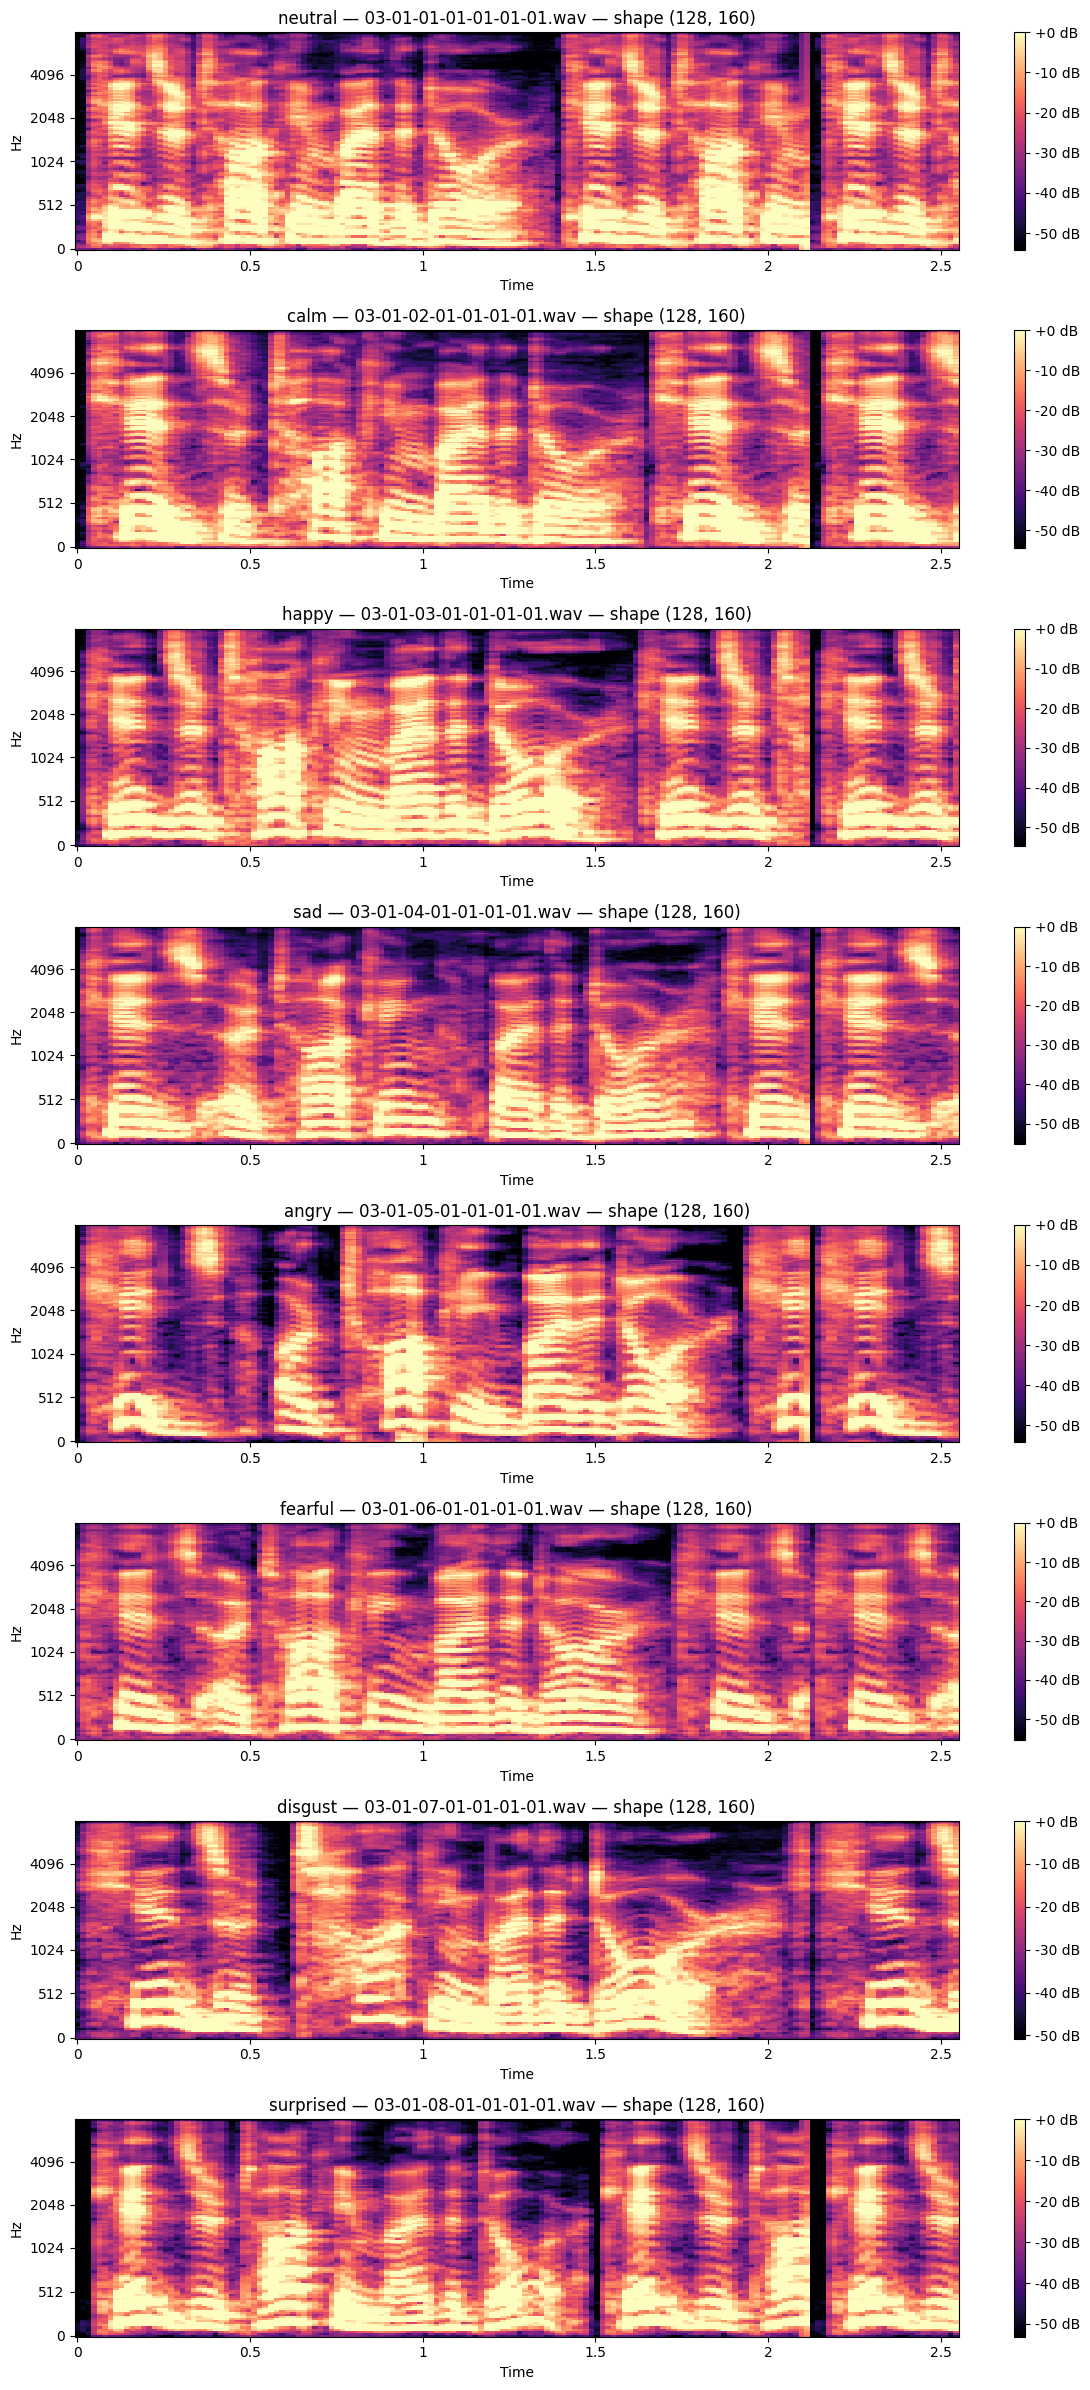

In [7]:
example_rows = records.groupby('emotion', group_keys=False).head(1).reset_index(drop=True)

fig, axes = plt.subplots(len(example_rows), 1, figsize=(12, 3 * len(example_rows)))
if len(example_rows) == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, example_rows.iterrows()):
    y, sr = load_clean_audio(row['path'])
    log_mel = waveform_to_log_mel(y, sr)
    img = librosa.display.specshow(log_mel, sr=sr, hop_length=HOP_LENGTH, x_axis='time', y_axis='mel', ax=ax)
    ax.set_title(f"{row['emotion']} — {Path(row['path']).name} — shape {log_mel.shape}")
    fig.colorbar(img, ax=ax, format='%+2.0f dB')

plt.tight_layout()
plt.show()

## 8. Actor-Wise Train / Validation / Test Split

We split by actor so that the model is evaluated on speakers it did not see during training.
This gives a more realistic result than random clip splitting.


In [8]:
all_idx = np.arange(len(records))
groups = records['actor_id'].to_numpy()

first_splitter = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
train_val_idx, test_idx = next(first_splitter.split(all_idx, groups=groups))

val_relative_size = 0.15 / (1.0 - 0.15)
second_splitter = GroupShuffleSplit(n_splits=1, test_size=val_relative_size, random_state=SEED + 1)
train_idx_local, val_idx_local = next(second_splitter.split(train_val_idx, groups=groups[train_val_idx]))

train_idx = train_val_idx[train_idx_local]
val_idx = train_val_idx[val_idx_local]

train_df = records.iloc[train_idx].reset_index(drop=True)
val_df = records.iloc[val_idx].reset_index(drop=True)
test_df = records.iloc[test_idx].reset_index(drop=True)


print('Train size:', len(train_df))
print('Validation size:', len(val_df))
print('Test size:', len(test_df))
print('Train actors:', sorted(train_df['actor_id'].unique().tolist()))
print('Validation actors:', sorted(val_df['actor_id'].unique().tolist()))
print('Test actors:', sorted(test_df['actor_id'].unique().tolist()))
print('Train emotion counts after neutral oversampling:')
print(train_df['emotion'].value_counts())


Train size: 960
Validation size: 240
Test size: 240
Train actors: [2, 3, 4, 5, 6, 7, 10, 11, 13, 14, 15, 16, 20, 21, 22, 23]
Validation actors: [8, 12, 18, 24]
Test actors: [1, 9, 17, 19]
Train emotion counts after neutral oversampling:
emotion
calm         128
happy        128
sad          128
angry        128
fearful      128
disgust      128
surprised    128
neutral       64
Name: count, dtype: int64


## 9. Convert Audio Into Xception Inputs

We first build fixed-size log-mel spectrograms.
Then we resize each spectrogram into a `160 x 160 x 3` image and apply Xception preprocessing.


In [9]:
IMAGE_SIZE = 160

def spectrogram_to_xception_input(spec: np.ndarray, image_size: int = IMAGE_SIZE) -> np.ndarray:
    spec = spec.astype(np.float32)
    scaled = (spec - LOG_MEL_MIN_DB) / (LOG_MEL_MAX_DB - LOG_MEL_MIN_DB)
    scaled = np.clip(scaled, 0.0, 1.0)
    scaled = (scaled * 255.0).astype(np.float32)
    scaled = scaled[..., np.newaxis]
    scaled = tf.image.resize(scaled, (image_size, image_size), method='bilinear').numpy()
    scaled = np.repeat(scaled, 3, axis=-1)
    return keras.applications.xception.preprocess_input(scaled)


def build_xception_dataset(df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    specs = []
    images = []
    labels = []
    for row in tqdm(df.itertuples(index=False), total=len(df), desc='Building Xception inputs'):
        y, sr = load_clean_audio(row.path)
        spec = waveform_to_log_mel(y, sr)
        specs.append(spec)
        images.append(spectrogram_to_xception_input(spec))
        labels.append(int(row.label_idx))
    return np.stack(specs).astype(np.float32), np.stack(images).astype(np.float32), np.array(labels, dtype=np.int64)


X_train_spec, X_train, y_train = build_xception_dataset(train_df)
X_val_spec, X_val, y_val = build_xception_dataset(val_df)
X_test_spec, X_test, y_test = build_xception_dataset(test_df)

print('Train spectrogram shape:', X_train_spec.shape)
print('Validation spectrogram shape:', X_val_spec.shape)
print('Test spectrogram shape:', X_test_spec.shape)
print('Xception input tensor shape:', X_train.shape)
print('One Xception input shape:', X_train[0].shape)
print('Xception input range:', float(X_train.min()), 'to', float(X_train.max()))
print('Classes:', len(emotion_labels))


Building Xception inputs:   0%|          | 0/960 [00:00<?, ?it/s]

Building Xception inputs:   0%|          | 0/240 [00:00<?, ?it/s]

Building Xception inputs:   0%|          | 0/240 [00:00<?, ?it/s]

Train spectrogram shape: (960, 128, 160)
Validation spectrogram shape: (240, 128, 160)
Test spectrogram shape: (240, 128, 160)
Xception input tensor shape: (960, 160, 160, 3)
One Xception input shape: (160, 160, 3)
Xception input range: -0.5740032196044922 to 1.0
Classes: 8


## 10. Visualize the CNN Inputs

This section shows the fixed-size log-mel spectrogram tensors that are fed to the CNN.


Raw spectrogram tensor shape: (960, 128, 160)
Xception input tensor shape: (960, 160, 160, 3)
One Xception input shape: (160, 160, 3)
Preprocessed value range: -0.5740032196044922 to 1.0


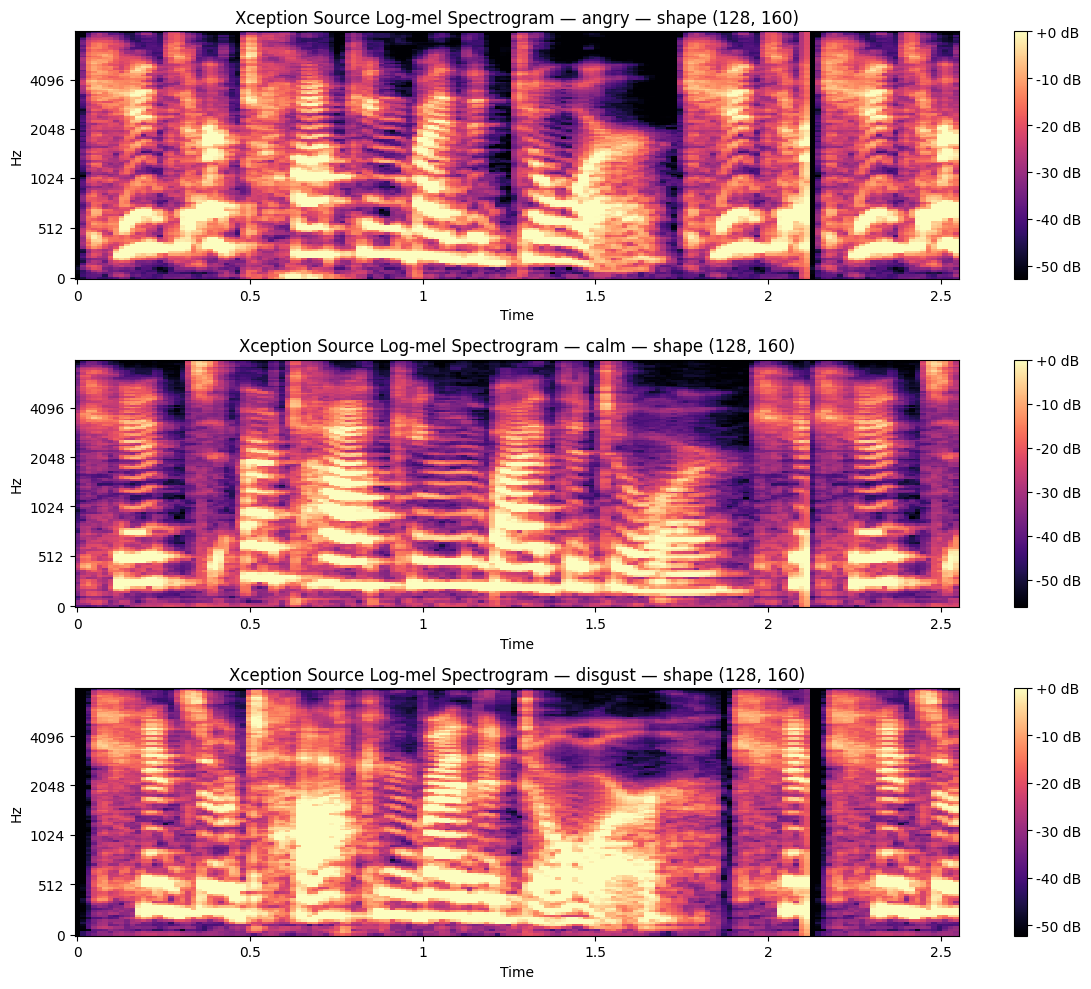

In [10]:
print('Raw spectrogram tensor shape:', X_train_spec.shape)
print('Xception input tensor shape:', X_train.shape)
print('One Xception input shape:', X_train[0].shape)
print('Preprocessed value range:', float(X_train.min()), 'to', float(X_train.max()))

fig, axes = plt.subplots(3, 1, figsize=(12, 10))
example_indices = []
for emotion in emotion_labels[:3]:
    idx = train_df.index[train_df['emotion'] == emotion][0]
    example_indices.append(idx)

for row_idx, sample_idx in enumerate(example_indices):
    spec = X_train_spec[sample_idx]
    label = idx_to_emotion[int(y_train[sample_idx])]
    ax = axes[row_idx]
    img_spec = librosa.display.specshow(spec, sr=SAMPLE_RATE, hop_length=HOP_LENGTH, x_axis='time', y_axis='mel', ax=ax)
    ax.set_title(f'Xception Source Log-mel Spectrogram — {label} — shape {spec.shape}')
    fig.colorbar(img_spec, ax=ax, format='%+2.0f dB')

plt.tight_layout()
plt.show()


## 11. Build a Simple CNN Classifier

We use a compact 2D CNN over the normalized log-mel spectrograms.


In [11]:
from tensorflow import keras

def build_xception_model(input_shape: tuple[int, int, int], num_classes: int) -> keras.Model:
    base_model = keras.applications.Xception(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape,
    )

    base_model.trainable = True
    for layer in base_model.layers[:-8]:
        layer.trainable = False

    inputs = keras.Input(shape=input_shape, name='xception_input')
    x = base_model(inputs, training=False)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dropout(0.50)(x)
    x = keras.layers.Dense(128, activation='relu')(x)
    x = keras.layers.Dropout(0.30)(x)
    outputs = keras.layers.Dense(num_classes, activation='softmax')(x)
    model = keras.Model(inputs, outputs, name='xception_mel_classifier')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=5e-5),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model


model = build_xception_model((IMAGE_SIZE, IMAGE_SIZE, 3), len(emotion_labels))
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {int(cls): float(weight) for cls, weight in zip(np.unique(y_train), class_weights)}

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    restore_best_weights=True,
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1,
)

print('Class weight dict:', class_weight_dict)
model.summary()


Class weight dict: {0: 0.9375, 1: 0.9375, 2: 0.9375, 3: 0.9375, 4: 0.9375, 5: 1.875, 6: 0.9375, 7: 0.9375}


Model: "xception_mel_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception_input (InputLayer)     │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 5, 5, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,124,784 (80.58 MB)

 Trainable params: 5,014,152 (19.13 MB)

 Non-trainable params: 16,110,632 (61.46 MB)

## 12. Train the Xception Model

We train a frozen pretrained Xception backbone on the spectrogram images.
This keeps the notebook focused on the transfer-learning experiment instead of the lighter simple CNN fallback.


In [12]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=[early_stopping, reduce_lr],
    verbose=1,
)

history_df = pd.DataFrame({
    'epoch': np.arange(1, len(history.history['loss']) + 1),
    'train_loss': history.history['loss'],
    'train_accuracy': history.history['accuracy'],
    'val_loss': history.history['val_loss'],
    'val_accuracy': history.history['val_accuracy'],
})

history_df


Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.1833 - loss: 2.0725 - val_accuracy: 0.1833 - val_loss: 2.0851 - learning_rate: 5.0000e-05
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.2896 - loss: 1.9252 - val_accuracy: 0.1917 - val_loss: 2.0899 - learning_rate: 5.0000e-05
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3737 - loss: 1.8171
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
60/60 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.3656 - loss: 1.7984 - val_accuracy: 0.2292 - val_loss: 2.1326 - learning_rate: 5.0000e-05
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 55s 913ms/step - accuracy: 0.4365 - loss: 1.6623 - val_accuracy: 0.2708 - val_loss: 1.9765 - learning_rate: 2.5000e-05
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 57s 947ms/step - accuracy: 0.5073 - loss: 1.5435 - val_accuracy: 0.3458 - val_loss: 1.8080 - learning_rate: 2.5000e-05
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.5021 - loss:

,epoch,train_loss,train_accuracy,val_loss,val_accuracy
0,1,2.072452,0.183333,2.085147,0.183333
1,2,1.925211,0.289583,2.089882,0.191667
2,3,1.798405,0.365625,2.132643,0.229167
3,4,1.662343,0.436458,1.976491,0.270833
4,5,1.543501,0.507292,1.808034,0.345833
5,6,1.486081,0.502083,1.679568,0.391667
6,7,1.392272,0.551042,1.604613,0.420833
7,8,1.307185,0.595833,1.578141,0.416667
8,9,1.242460,0.589583,1.558374,0.454167
9,10,1.177700,0.606250,1.537998,0.437500


## 13. Plot Training History


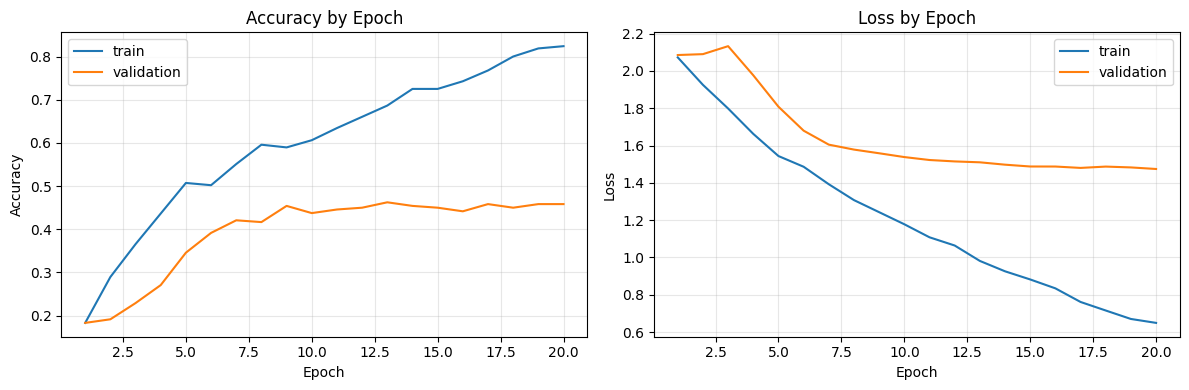

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df['epoch'], history_df['train_accuracy'], label='train')
axes[0].plot(history_df['epoch'], history_df['val_accuracy'], label='validation')
axes[0].set_title('Accuracy by Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_df['epoch'], history_df['train_loss'], label='train')
axes[1].plot(history_df['epoch'], history_df['val_loss'], label='validation')
axes[1].set_title('Loss by Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 14. Test Evaluation and Report Generation

This section evaluates the trained CNN on the held-out actor-wise test split and saves:
- test accuracy
- macro F1
- classification report
- confusion matrix
- training history


In [14]:
test_probs = model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
all_test_preds = np.argmax(test_probs, axis=1)
all_test_targets = y_test

test_accuracy = accuracy_score(all_test_targets, all_test_preds)
test_macro_f1 = f1_score(all_test_targets, all_test_preds, average='macro')
label_ids = list(range(len(emotion_labels)))
report_text = classification_report(all_test_targets, all_test_preds, labels=label_ids, target_names=emotion_labels, digits=4, zero_division=0)
report_dict = classification_report(all_test_targets, all_test_preds, labels=label_ids, target_names=emotion_labels, digits=4, output_dict=True, zero_division=0)
cm = confusion_matrix(all_test_targets, all_test_preds, labels=label_ids)

metrics = {
    'test_accuracy': float(test_accuracy),
    'test_macro_f1': float(test_macro_f1),
    'num_train': int(len(train_df)),
    'num_val': int(len(val_df)),
    'num_test': int(len(test_df)),
    'sample_rate': int(SAMPLE_RATE),
    'duration_seconds': float(DURATION_SECONDS),
    'target_num_samples': int(TARGET_NUM_SAMPLES),
    'n_mels': int(N_MELS),
    'target_spec_frames': int(TARGET_SPEC_FRAMES),
    'xception_input_shape': list(X_train.shape[1:]),
    'emotion_labels': emotion_labels,
    'backbone': 'Xception',
    'epochs': int(EPOCHS),
    'batch_size': int(BATCH_SIZE),
}

model.save(ARTIFACTS_DIR / 'xception_model.keras')
(ARTIFACTS_DIR / 'xception_metrics.json').write_text(json.dumps(metrics, indent=2))
(ARTIFACTS_DIR / 'xception_classification_report.json').write_text(json.dumps(report_dict, indent=2))
(ARTIFACTS_DIR / 'xception_classification_report.txt').write_text(report_text)
history_df.to_csv(ARTIFACTS_DIR / 'xception_training_history.csv', index=False)
np.save(ARTIFACTS_DIR / 'xception_confusion_matrix.npy', cm)

print('Test accuracy:', round(test_accuracy, 4))
print('Test macro F1:', round(test_macro_f1, 4))
print()
print('Classification report:')
print()
print(report_text)

metrics


15/15 ━━━━━━━━━━━━━━━━━━━━ 51s 3s/step
Test accuracy: 0.3875
Test macro F1: 0.3905

Classification report:

              precision    recall  f1-score   support

       angry     0.5263    0.3125    0.3922        32
        calm     0.4211    0.5000    0.4571        32
     disgust     0.5357    0.4688    0.5000        32
     fearful     0.2917    0.2188    0.2500        32
       happy     0.5556    0.3125    0.4000        32
     neutral     0.3235    0.6875    0.4400        16
         sad     0.2045    0.2812    0.2368        32
   surprised     0.4286    0.4688    0.4478        32

    accuracy                         0.3875       240
   macro avg     0.4109    0.4062    0.3905       240
weighted avg     0.4167    0.3875    0.3872       240



{'test_accuracy': 0.3875,
 'test_macro_f1': 0.3904878773976205,
 'num_train': 960,
 'num_val': 240,
 'num_test': 240,
 'sample_rate': 16000,
 'duration_seconds': 2.112,
 'target_num_samples': 33792,
 'n_mels': 128,
 'target_spec_frames': 160,
 'xception_input_shape': [160, 160, 3],
 'emotion_labels': ['angry',
  'calm',
  'disgust',
  'fearful',
  'happy',
  'neutral',
  'sad',
  'surprised'],
 'backbone': 'Xception',
 'epochs': 20,
 'batch_size': 16}

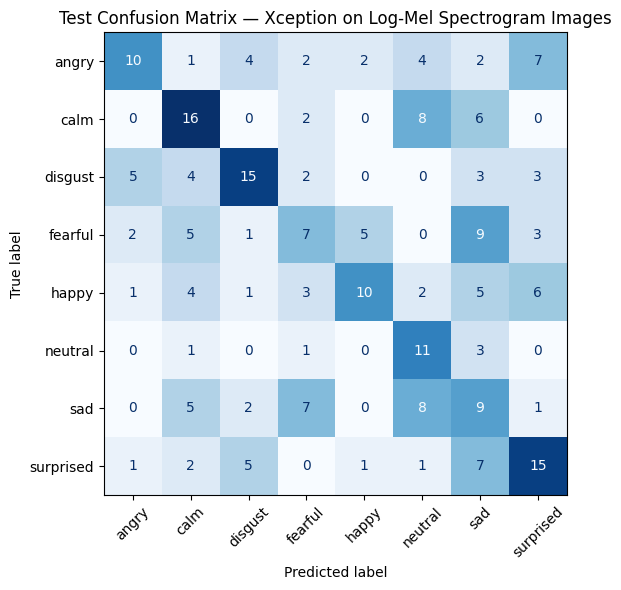

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=emotion_labels).plot(ax=ax, cmap='Blues', xticks_rotation=45, colorbar=False)
ax.set_title('Test Confusion Matrix — Xception on Log-Mel Spectrogram Images')
plt.tight_layout()
plt.show()


## 15. Summary of What This Notebook Demonstrates

This notebook gives a transfer-learning Xception spectrogram baseline for emotion recognition:
- silence removal
- equal-length waveforms
- fixed-size log-mel spectrograms
- spectrogram-to-image conversion for Xception
- frozen pretrained Xception classification head
- speaker-independent evaluation
